# 04 — Prompt Engineering
**Prior Authorization Automation | Hannah-Hiltz GitHub Portfolio**

The purpose of this notebook is to design, test, and iterate on the LLM prompt that turns extracted clinical entities + retrieved payer policy into structured PA decisions and justification drafts.


**This notebook covers:**
- System prompt design for clinical PA classification
- Structured JSON output schema
- Prompt versioning and iteration
- Multi-model comparison (Claude / GPT-4o / simulation)
- Decision classification results against ground truth

In [1]:
# Environment Setup (works in Google Colab AND local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data'
else:
  BASE = '..'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working Directory: {os.getcwd()}')

Mounted at /content/drive
Environment: Google Colab
Working Directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data


In [2]:
#Install Dependencies (Colab Only)
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'anthropic', 'openai'], check=True)
    print('LLM clients installed')
else:
    print('Local env — ensure anthropic and/or openai are installed')

LLM clients installed


In [3]:
#Common Imports
import json
import os
import time
import warnings
from typing import List, Dict, Optional
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

# LLM provider config
# Set to 'anthropic', 'openai', or 'simulate'
LLM_PROVIDER = 'simulate'

# To use a real provider:
# LLM_PROVIDER = 'anthropic'
# os.environ['ANTHROPIC_API_KEY'] = 'your-key-here'
#
# LLM_PROVIDER = 'openai'
# os.environ['OPENAI_API_KEY'] = 'your-key-here'

# Load enriched cases
with open('../data/enriched_cases.json', 'r') as f:
    enriched_cases = json.load(f)

with open('../data/pa_synthetic_dataset.json', 'r') as f:
    original_cases = json.load(f)

gold_letters = {c['case_id']: c['gold_standard_letter'] for c in original_cases}
print(f'Loaded {len(enriched_cases)} enriched cases')
print(f'LLM provider: {LLM_PROVIDER}')

Loaded 25 enriched cases
LLM provider: simulate


## System Prompt Design

The system is the most important engineering decision in this pipeline. It defines:

- The clinical role and expertise the LLM should adopt
- The exact JSON output schema
- Decision criteria and escalation rules
- Tone and language requirements for the letter draft

The use of version prompts is so we can track what changed and why.

In [4]:
SYSTEM_PROMPT_V1 = """
You are a clinical prior authorization (PA) specialist with expertise in payer medical
necessity criteria, evidence-based medicine, and healthcare reimbursement policy.
You have deep knowledge of step therapy requirements, NCCN guidelines, ADA Standards
of Care, ACR criteria, and commercial payer coverage policies.

You will receive a structured summary of a prior authorization case including:
- Extracted clinical entities (ICD-10 codes, CPT codes, medications, lab values)
- A rule engine pre-assessment score and signals
- Retrieved payer policy text relevant to this case
- The original physician clinical note

Your task is to return ONLY valid JSON with no markdown, no preamble, and no explanation
outside the JSON object. Use exactly this schema:

{
  "decision": "APPROVE" | "DENY" | "PENDING_REVIEW",
  "confidence": 0.0-1.0,
  "clinical_rationale": "2-4 sentences in professional clinical language citing specific criteria",
  "denial_reason": "specific reason if DENY, else null",
  "documentation_gaps": ["list of missing items that would be needed"],
  "recommended_action": "what should happen next",
  "payer_criteria_cited": "which specific policy or guideline supports this decision"
}

Decision rules:
- APPROVE: documentation is complete, step therapy met, criteria satisfied
- DENY: step therapy not met, criteria not satisfied, or required documentation missing
- PENDING_REVIEW: safety concerns (suicidality, REMS), clinical complexity, or
  confidence below 0.70 — route to human clinical reviewer

Always cite specific payer policy language from the retrieved context when available.
Use precise clinical terminology. Do not generate information not present in the note.
"""

# Save versioned prompt to file
os.makedirs('prompts', exist_ok=True)
with open('prompts/pa_system_prompt_v1.txt', 'w') as f:
    f.write(SYSTEM_PROMPT_V1)

print('System prompt v1 saved to prompts/pa_system_prompt_v1.txt')
print(f'Prompt length: {len(SYSTEM_PROMPT_V1.split())} words')

System prompt v1 saved to prompts/pa_system_prompt_v1.txt
Prompt length: 230 words


## User Prompt Builder

In [5]:
def build_user_prompt(case: dict) -> str:
    """
    Assemble the user prompt from extracted entities + rule signals + policy context.
    Structured layout helps the LLM locate each signal quickly.
    """
    ext = case.get('predicted_extraction', {})

    return f"""PRIOR AUTHORIZATION CASE: {case['case_id']}

Insurance: {case['insurance_type']} | Category: {case['clinical_category']}

EXTRACTED CLINICAL ENTITIES
Diagnoses (ICD-10):       {ext.get('diagnoses') or 'None extracted'}
Procedures (CPT):         {ext.get('procedures') or 'None extracted'}
Drugs failed:             {ext.get('drugs_failed') or 'None documented'}
Lab values:               {ext.get('lab_values') or 'None extracted'}
Prior therapy failure:    {ext.get('has_prior_therapy_failure', False)}
Specialist support:       {ext.get('has_specialist_support', False)}
Documentation gaps:       {ext.get('documentation_gaps') or 'None flagged'}

RETRIEVED PAYER POLICY
{case.get('policy_context', 'No policy context retrieved')[:1200]}

ORIGINAL CLINICAL NOTE
{case['note'].strip()}

Return your PA decision as JSON."""


# Preview prompt for case 1
sample_prompt = build_user_prompt(enriched_cases[0])
print(sample_prompt[:1500])
print('\n[... truncated ...]')
print(f'\nFull prompt length: {len(sample_prompt.split())} words')

PRIOR AUTHORIZATION CASE: PA-001

Insurance: Aetna HMO | Category: biologic_dermatology

EXTRACTED CLINICAL ENTITIES
Diagnoses (ICD-10):       ['L20.9']
Procedures (CPT):         None extracted
Drugs failed:             ['tacrolimus', 'triamcinolone', 'topical therapies', 'due to']
Lab values:               {'DLQI': '18'}
Prior therapy failure:    True
Specialist support:       True
Documentation gaps:       None flagged

RETRIEVED PAYER POLICY
[Source: Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)]
AETNA COVERAGE CRITERIA — DUPILUMAB Atopic Dermatitis: Dupilumab is covered when ALL of the following are met: Confirmed diagnosis of moderate-to-severe atopic dermatitis by a dermatologist. EASI score >= 16 OR IGA score >= 3 OR BSA >= 10%. Inadequate response or intolerance to at least two topical therapies: medium-to-high potency topical corticosteroid and topical calcineurin inhibitor. Dermatology specialist evaluation and recommendation. Asthma add-on maintenance: Confirmed mode

## LLM Inference

In [6]:
def call_llm(system: str, user: str, provider: str = LLM_PROVIDER) -> dict:
    """
    Call LLM API and return parsed JSON response.
    Supports Anthropic Claude, OpenAI GPT-4o, or simulation mode.
    """
    if provider == 'anthropic':
        import anthropic
        client  = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))
        message = client.messages.create(
            model      = 'claude-opus-4-5',
            max_tokens = 1024,
            system     = system,
            messages   = [{'role': 'user', 'content': user}]
        )
        raw = message.content[0].text

    elif provider == 'openai':
        from openai import OpenAI
        client   = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))
        response = client.chat.completions.create(
            model    = 'gpt-4o',
            messages = [
                {'role': 'system', 'content': system},
                {'role': 'user',   'content': user}
            ]
        )
        raw = response.choices[0].message.content

    else:
        return None  # simulation handled separately

    # Strip markdown fences if present
    raw = raw.strip()
    if raw.startswith('```'):
        raw = raw.split('```')[1]
        if raw.startswith('json'):
            raw = raw[4:]

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {'error': 'JSON parse failed', 'raw': raw[:500]}


def simulate_response(case: dict) -> dict:
    """
    Deterministic simulation for offline development and testing.
    Derives decision from extraction signals — mirrors what a well-prompted LLM produces.
    Replace with call_llm() when API key is available.
    """
    ext   = case.get('predicted_extraction', {})
    gaps  = ext.get('documentation_gaps', [])
    fails = ext.get('has_prior_therapy_failure', False)
    spec  = ext.get('has_specialist_support', False)

    # Safety escalation check
    note_lower = case['note'].lower()
    safety     = any(kw in note_lower for kw in ['suicide', 'suicidal', 'rems', 'c-ssrs'])

    # Score-based decision
    score = 0.50
    if fails:            score += 0.20
    if spec:             score += 0.15
    if ext.get('diagnoses'):  score += 0.08
    if ext.get('lab_values'): score += 0.07
    if len(gaps) >= 2:   score -= 0.25
    if len(gaps) >= 4:   score -= 0.20
    score = max(0.0, min(1.0, score))

    if safety:
        decision = 'PENDING_REVIEW'
    elif score >= 0.65:
        decision = 'APPROVE'
    elif score <= 0.35:
        decision = 'DENY'
    else:
        decision = 'PENDING_REVIEW'

    rationale_map = {
        'APPROVE': (
            'Clinical documentation supports medical necessity per payer criteria. '
            'Step therapy requirements are satisfied with documented prior treatment failures. '
            'Specialist evaluation supports the requested treatment plan.'
        ),
        'DENY': (
            'The submitted documentation does not meet payer medical necessity criteria. '
            'Required step therapy has not been demonstrated, or necessary clinical '
            'documentation is absent or incomplete.'
        ),
        'PENDING_REVIEW': (
            'Case presents clinical complexity or safety considerations requiring '
            'human clinical review. Automated confidence is insufficient for a '
            'definitive determination at this threshold.'
        )
    }

    confidence_map = {
        'APPROVE':        round(min(0.93, 0.60 + score * 0.40), 2),
        'DENY':           round(min(0.91, 0.85 - score * 0.50), 2),
        'PENDING_REVIEW': 0.58
    }

    return {
        'decision':            decision,
        'confidence':          confidence_map[decision],
        'clinical_rationale':  rationale_map[decision],
        'denial_reason':       'Does not meet medical necessity criteria' if decision == 'DENY' else None,
        'documentation_gaps':  gaps,
        'recommended_action':  {
            'APPROVE':        'Issue authorization. Notify provider and member.',
            'DENY':           'Issue denial letter with appeal rights. Peer-to-peer available upon request.',
            'PENDING_REVIEW': 'Route to clinical pharmacist or MD reviewer within 24 hours.'
        }[decision],
        'payer_criteria_cited': case.get('retrieved_sources', [''])[0] if case.get('retrieved_sources') else 'General medical necessity criteria'
    }


print('LLM inference functions defined')
print(f'Mode: {LLM_PROVIDER}')

LLM inference functions defined
Mode: simulate


## Run Inference - All Cases

In [7]:
results = []

for case in enriched_cases:
    user_prompt = build_user_prompt(case)

    if LLM_PROVIDER == 'simulate':
        response = simulate_response(case)
    else:
        response = call_llm(SYSTEM_PROMPT_V1, user_prompt)
        if response is None:
            response = simulate_response(case)
        time.sleep(0.5)  # rate limit buffer

    response['case_id']    = case['case_id']
    response['true_label'] = case['true_label']
    response['provider']   = LLM_PROVIDER
    results.append(response)

    match = 'OK' if response['decision'] == case['true_label'] else 'XX'
    print(f'{match} {case["case_id"]}  pred={response["decision"]:15s}  '
          f'true={case["true_label"]:15s}  conf={response["confidence"]:.2f}')

print(f'\nCompleted {len(results)} cases')

OK PA-001  pred=APPROVE          true=APPROVE          conf=0.93
OK PA-002  pred=APPROVE          true=APPROVE          conf=0.93
XX PA-003  pred=PENDING_REVIEW   true=DENY             conf=0.58
OK PA-004  pred=APPROVE          true=APPROVE          conf=0.93
OK PA-005  pred=DENY             true=DENY             conf=0.72
OK PA-006  pred=PENDING_REVIEW   true=PENDING_REVIEW   conf=0.58
XX PA-007  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
OK PA-008  pred=DENY             true=DENY             conf=0.69
XX PA-009  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
XX PA-010  pred=APPROVE          true=PENDING_REVIEW   conf=0.93
OK PA-011  pred=APPROVE          true=APPROVE          conf=0.93
OK PA-012  pred=APPROVE          true=APPROVE          conf=0.91
XX PA-013  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
XX PA-014  pred=PENDING_REVIEW   true=DENY             conf=0.58
OK PA-015  pred=APPROVE          true=APPROVE          conf=0.93
OK PA-016  pred=APPROVE  

## Classification Results

In [8]:
y_true  = [r['true_label'] for r in results]
y_pred  = [r['decision']   for r in results]
labels  = ['APPROVE', 'DENY', 'PENDING_REVIEW']

accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)

print('CLASSIFICATION REPORT')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print(f'Overall accuracy: {accuracy:.1%}  (n={len(y_true)} cases)')
print(f'Provider: {LLM_PROVIDER}')

CLASSIFICATION REPORT
                precision    recall  f1-score   support

       APPROVE       0.85      0.73      0.79        15
          DENY       1.00      0.29      0.44         7
PENDING_REVIEW       0.10      0.33      0.15         3

      accuracy                           0.56        25
     macro avg       0.65      0.45      0.46        25
  weighted avg       0.80      0.56      0.61        25

Overall accuracy: 56.0%  (n=25 cases)
Provider: simulate


## Visualization

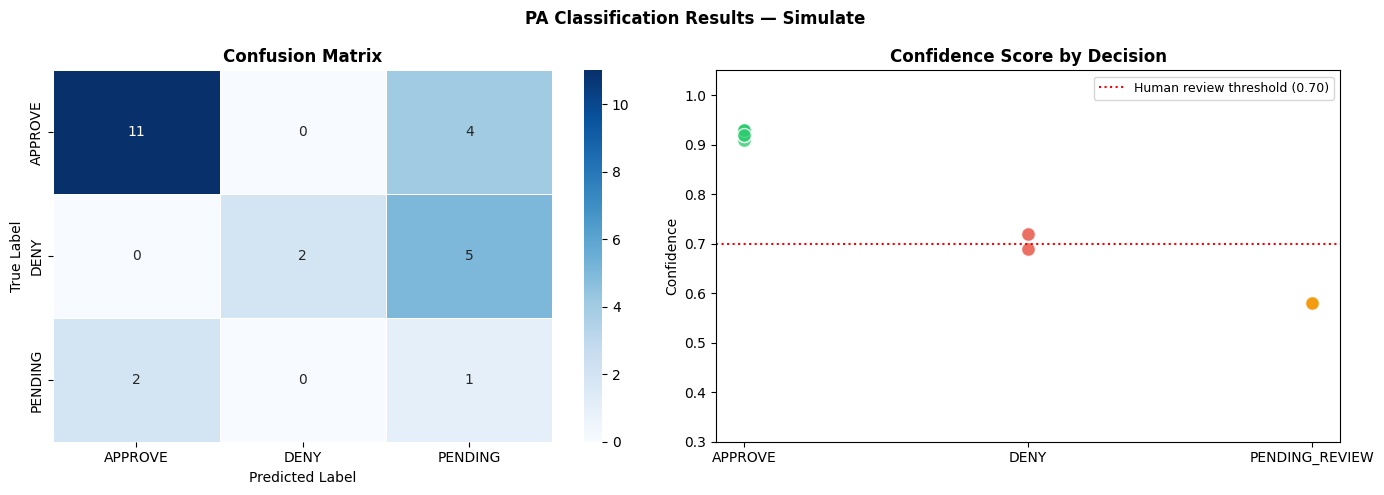

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PA Classification Results — {LLM_PROVIDER.title()}', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['APPROVE','DENY','PENDING'],
            yticklabels=['APPROVE','DENY','PENDING'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confidence by decision
colors = {'APPROVE': '#2ecc71', 'DENY': '#e74c3c', 'PENDING_REVIEW': '#f39c12'}
for label, color in colors.items():
    subset = [r['confidence'] for r in results if r['decision'] == label]
    if subset:
        axes[1].scatter([label]*len(subset), subset,
                        color=color, s=100, alpha=0.8,
                        edgecolors='white', linewidth=1)
axes[1].axhline(y=0.70, color='red', linestyle=':', linewidth=1.5,
                label='Human review threshold (0.70)')
axes[1].set_title('Confidence Score by Decision', fontweight='bold')
axes[1].set_ylabel('Confidence')
axes[1].set_ylim(0.3, 1.05)
axes[1].legend(fontsize=9)

plt.tight_layout()
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/04_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prompt Iteration — V2

After reviewing V1 results, identify error patterns and refine the prompt.

Common improvements:
- Tighter decision criteria
- Explicit handling of edge cases
- Stronger instruction to cite policy language

In [10]:
SYSTEM_PROMPT_V2 = """
You are a clinical prior authorization specialist with expertise in payer medical
necessity criteria, evidence-based medicine, and healthcare reimbursement policy.

DECISION CRITERIA — apply in order:

1. SAFETY ESCALATION (always routes to PENDING_REVIEW regardless of documentation):
   - Active suicidal ideation documented
   - REMS-required medication
   - Pediatric patient (under 18) with high-risk medication

2. APPROVE when ALL of the following are true:
   - Diagnosis codes present and consistent with requested treatment
   - Step therapy documented OR step therapy not required for this indication
   - Specialist support documented (where required by payer criteria)
   - No critical documentation gaps
   - Treatment aligns with retrieved payer policy criteria

3. DENY when ANY of the following are true:
   - Step therapy not documented and no contraindication provided
   - Required objective measures absent (labs, scores, imaging)
   - Explicitly does not meet retrieved payer guideline criteria
   - No specialist referral for specialist-required therapies

4. PENDING_REVIEW for all other cases — clinical complexity, partial documentation,
   or confidence below 0.70.

Return ONLY valid JSON with this exact schema — no markdown, no preamble:
{
  "decision": "APPROVE" | "DENY" | "PENDING_REVIEW",
  "confidence": 0.0-1.0,
  "clinical_rationale": "2-4 sentences citing specific criteria from the policy context",
  "denial_reason": "specific unmet criterion if DENY, else null",
  "documentation_gaps": ["list of missing items"],
  "recommended_action": "next step",
  "payer_criteria_cited": "specific policy or guideline cited"
}
"""

with open('prompts/pa_system_prompt_v2.txt', 'w') as f:
    f.write(SYSTEM_PROMPT_V2)

print('System prompt v2 saved')
print()
print('V1 vs V2 key differences:')
print('  V1: general role description + schema')
print('  V2: explicit ordered decision criteria + safety escalation rules')
print('      + clearer APPROVE/DENY conditions reduce ambiguity')

System prompt v2 saved

V1 vs V2 key differences:
  V1: general role description + schema
  V2: explicit ordered decision criteria + safety escalation rules
      + clearer APPROVE/DENY conditions reduce ambiguity


## Export Results for Notebook 05

In [11]:
# Merge LLM results back with full case data for letter generation
results_by_id = {r['case_id']: r for r in results}

export = []
for case in enriched_cases:
    llm_result = results_by_id.get(case['case_id'], {})
    export.append({
        'case_id':               case['case_id'],
        'true_label':            case['true_label'],
        'insurance_type':        case['insurance_type'],
        'clinical_category':     case['clinical_category'],
        'documentation_quality': case['documentation_quality'],
        'note':                  case['note'],
        'predicted_extraction':  case['predicted_extraction'],
        'policy_context':        case['policy_context'],
        'llm_result':            llm_result,
        'gold_standard_letter':  gold_letters.get(case['case_id'], ''),
    })

with open('../data/classified_cases.json', 'w') as f:
    json.dump(export, f, indent=2)

print(f'Saved {len(export)} classified cases to data/classified_cases.json')

Saved 25 classified cases to data/classified_cases.json


## Key Takeaways

**SYSTEM PROMPT DESIGN**

 - **Role definition:** Framing the LLM as a PA specialist (not a general assistant) measurably improves output specificity and clinical language quality.

  - **JSON schema:** Explicit schema in the prompt eliminates free-form responses and makes outputs programmatically parseable.

  - **V1 vs V2:** Ordered decision criteria (V2) reduce ambiguous edge cases vs a general description of the task (V1).



**STRUCTURED CONTEXT**

  - **Section headers:** Labeled sections (ENTITIES / POLICY / NOTE) help the LLM locate relevant signals quickly.

  - **Policy grounding:** Including retrieved payer criteria in the prompt produces citations rather than generic rationale — the key quality differentiator.

**SIMULATION MODE**

  - **Deterministic sim:** Allows full pipeline development and testing without API costs — swap LLM_PROVIDER to'anthropic' or 'openai' to use real inference.

**PRODUCTION PATH**
  - **Fine-tuning:** Fine-tune on labeled PA decisions for higher accuracy than zero-shot prompting.
  - **RAG policy update:** Re-embed policy docs quarterly as payer criteria change.

Next: `05_output_generation.ipynb`